# Read compiled ITCHI event

This notebook reads a compiled ITCHI event previously exported as NetCDF or Zarr. The purpose is to validate that event-level ITCHI products can be consumed without recomputing the index.

This notebook assumes that the synthetic event file was generated with:

```bash
python examples/smoke_test_synthetic.py \
  --output-path outputs/events/smoke_test_synthetic.nc
```

## 1. Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt

from itchi.io import read_dataset

## 2. Input file

In [2]:
input_path = Path('../outputs/events/smoke_test_synthetic.nc')

if not input_path.exists():
    raise FileNotFoundError(
        f'Compiled event file not found: {input_path}. '
        'Run examples/smoke_test_synthetic.py first.'
    )

input_path

PosixPath('../outputs/events/smoke_test_synthetic.nc')

## 3. Read compiled event

In [3]:
ds = read_dataset(input_path)
ds

<xarray.Dataset> Size: 1MB
Dimensions:     (time: 2, y: 81, x: 81)
Dimensions without coordinates: time, y, x
Data variables: (12/16)
    radius_km   (time, y, x) float64 105kB ...
    quadrant    (time, y, x) <U3 157kB ...
    R_direct_q  (time, y, x) float64 105kB ...
    ROCLOUD_q   (time, y, x) float64 105kB ...
    M_direct    (time, y, x) bool 13kB ...
    M_indirect  (time, y, x) bool 13kB ...
    ...          ...
    H_W         (time, y, x) float64 105kB ...
    H_dir       (time, y, x) float64 105kB ...
    H_ind       (time, y, x) float64 105kB ...
    ITCHI       (time, y, x) float64 105kB ...
    ITCHI_max   (y, x) float64 52kB ...
    ITCHI_acc   (y, x) float64 52kB ...
Attributes:
    title:                        Synthetic ITCHI smoke test
    storm_id:                     SYNTHETIC
    itchi_version:                0.1
    precipitation_treatment:      snapshot_not_accumulation
    description:                  Synthetic end-to-end ITCHI event generated ...
    snapshot_metadata_json:       [{"time": "2020-09-01T00:00", "R_direct_sou...
    n_snapshot_metadata_records:  2

## 4. Inspect dimensions and variables

In [4]:
print('Dimensions:')
for name, size in ds.sizes.items():
    print(f'  {name}: {size}')

print('\nVariables:')
for name in ds.data_vars:
    print(f'  {name}: dims={ds[name].dims}, shape={ds[name].shape}')

Dimensions:
  time: 2
  y: 81
  x: 81

Variables:
  radius_km: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  quadrant: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  R_direct_q: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  ROCLOUD_q: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  M_direct: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  M_indirect: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  M_exterior: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  H_P: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  H_Pdir: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  H_Pind: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  H_W: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  H_dir: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  H_ind: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  ITCHI: dims=('time', 'y', 'x'), shape=(2, 81, 81)
  ITCHI_max: dims=('y', 'x'), shape=(81, 81)
  ITCHI_acc: dims=('y', 'x'), shape=(81, 81)


## 5. Inspect metadata

In [5]:
print('Global attributes:')
for key, value in ds.attrs.items():
    if key == 'snapshot_metadata_json':
        print(f'{key}: <serialized metadata>')
    else:
        print(f'{key}: {value}')

metadata = json.loads(ds.attrs.get('snapshot_metadata_json', '[]'))
metadata

Global attributes:
title: Synthetic ITCHI smoke test
storm_id: SYNTHETIC
itchi_version: 0.1
precipitation_treatment: snapshot_not_accumulation
description: Synthetic end-to-end ITCHI event generated for workflow validation.
snapshot_metadata_json: <serialized metadata>
n_snapshot_metadata_records: 2


[{'time': '2020-09-01T00:00',
  'R_direct_source': 'R34',
  'R_direct_filled_quadrants': [],
  'R_direct_used_fallback': False,
  'ROCLOUD_source': 'observed',
  'ROCLOUD_filled_quadrants': [],
  'wind_hazard_source': 'radial_profile'},
 {'time': '2020-09-01T06:00',
  'R_direct_source': 'R34',
  'R_direct_filled_quadrants': [],
  'R_direct_used_fallback': False,
  'ROCLOUD_source': 'observed',
  'ROCLOUD_filled_quadrants': [],
  'wind_hazard_source': 'radial_profile'}]

## 6. Validate required variables

In [6]:
required_variables = ['ITCHI', 'ITCHI_max', 'ITCHI_acc']
missing = [name for name in required_variables if name not in ds]

if missing:
    raise KeyError(f'Missing required variables: {missing}')

for name in required_variables:
    min_value = float(ds[name].min(skipna=True))
    max_value = float(ds[name].max(skipna=True))
    print(f'{name}: min={min_value:.3f}, max={max_value:.3f}')

    if min_value < 0.0 or max_value > 1.0:
        raise ValueError(f'{name} is outside [0, 1].')

ITCHI: min=0.000, max=1.000
ITCHI_max: min=0.000, max=1.000
ITCHI_acc: min=0.000, max=1.000


## 7. Validate event-product structure

In [7]:
if 'time' not in ds['ITCHI'].dims:
    raise ValueError('ITCHI must contain a time dimension.')

if 'time' in ds['ITCHI_max'].dims:
    raise ValueError('ITCHI_max should not contain time.')

if 'time' in ds['ITCHI_acc'].dims:
    raise ValueError('ITCHI_acc should not contain time.')

print('Event-product structure is valid.')

Event-product structure is valid.


## 8. Plot diagnostic fields

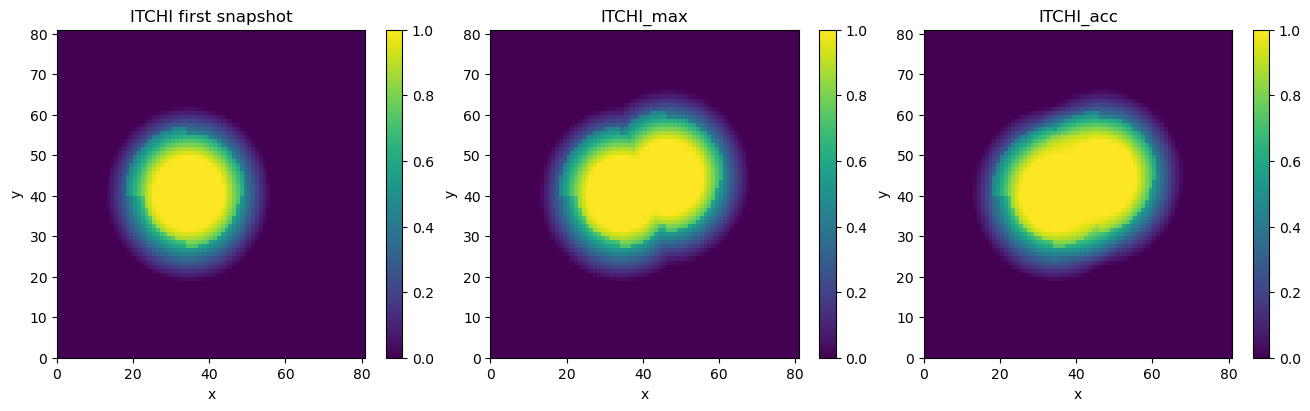

In [8]:
fields = [
    (ds['ITCHI'].isel(time=0), 'ITCHI first snapshot'),
    (ds['ITCHI_max'], 'ITCHI_max'),
    (ds['ITCHI_acc'], 'ITCHI_acc'),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)

for ax, (field, title) in zip(axes, fields, strict=False):
    image = ax.pcolormesh(field.values, shading='auto')
    ax.set_title(title)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    fig.colorbar(image, ax=ax)

plt.show()

## 9. Close dataset

In [9]:
ds.close()